---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">Checkpoint 02 — CNN Multiclasse</h3>

<h4 align="center">PhD. Julles Mitoura</h4>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/NumPy-013243?style=for-the-badge&logo=numpy&logoColor=white"/>
</div>

---

**Disciplina:** Redes Neurais Artificiais e Deep Learning  
**Turma:** 1TIAPF — FIAP  
**Atividade:** Avaliativa (Checkpoint 02)  
**Tema:** Redes Neurais Convolucionais (CNN) aplicadas à classificação multiclasse de formas geométricas

**Membros:**
- João Pedro Morangoni - rm570073
- Davi Oliveira da Silva - rm569108
- Brian Barreto Brasil - rm570384
- Victor Deggerone Gomes - rm569518
- João Vitor Xavier de Carvalho - rm570633


## 1. Contexto

Na aula `aula7_redes_neurais_cnn_1.ipynb` construímos uma **CNN do zero**, usando apenas NumPy, para classificar dois padrões 6×6: o **O** e o **X**. Implementamos manualmente:

- a operação de **convolução 2D** (`conv2d`),
- a função de ativação **ReLU**,
- o **Max Pooling 2×2**,
- a camada **Densa** com **softmax** + **cross-entropy**,
- e o **backpropagation** completo (gradientes da convolução, do pooling, da ReLU e da camada densa).

Naquela aula o problema era **binário** (2 classes). Agora vamos generalizar.

---

## 2. Objetivo do Checkpoint

Adaptar a CNN da aula 07 para um problema de **classificação multiclasse com 4 categorias**, treinada exclusivamente com **NumPy** (sem PyTorch / TensorFlow / Keras).

As classes a serem reconhecidas são padrões 6×6 binários:

| Rótulo | Classe | Descrição |
|--------|---------|-----------|
| 0 | **X** | Duas diagonais cruzadas |
| 1 | **Quadrado** | Contorno retangular |
| 2 | **Bola** | Contorno arredondado |
| 3 | **Triângulo** | Apex no topo, base na linha de baixo |

O dataset é gerado a partir de um padrão base de cada classe, somado a ruído gaussiano (a função sugerida está no item **5**).


## 3. O que você precisa entregar

Um único notebook **resolvido e comentado**, contendo:

1. **Carregamento e visualização** dos 4 padrões base e de exemplos do dataset com ruído.
2. **Implementação da CNN em NumPy** capaz de classificar as 4 classes. Você pode partir do código da aula 07, mas precisará **adaptar pelo menos**:
   - a saída da camada densa (de 2 para 4 neurônios),
   - o vetor *one-hot* do rótulo no `backward`,
   - a inicialização dos pesos.
3. **Justificativa das escolhas de arquitetura** em células markdown:
   - Quantos filtros convolucionais? Por quê?
   - Tamanho do filtro (3×3, 4×4, ...)? Por quê?
   - Você usou pooling? Qual tipo, qual tamanho? Por quê?
   - Quantos neurônios na camada densa? Por quê?
4. **Treinamento** com SGD (mínimo de 20 épocas) e **registro da curva de loss**.
5. **Avaliação no conjunto de teste**, reportando:
   - Acurácia global,
   - Matriz de confusão (pode ser feita manualmente com NumPy),
   - Pelo menos **8 exemplos visuais** com `Real` × `Predito`.
6. **Discussão final (markdown)** respondendo:
   - Quais classes a rede confunde mais? Por quê?
   - O que acontece quando você aumenta o ruído do dataset?
   - Qual a vantagem da CNN frente a uma FNN para este problema (justifique com o número de parâmetros)?

> **Importante:** o notebook deve estar **executado** (com saídas visíveis) e **comentado**. Células sem nenhum comentário ou justificativa perdem pontos mesmo que o código esteja correto.


## 4. Restrições técnicas

- Use **apenas NumPy** para a rede neural. `matplotlib` é permitido para visualização.
- **Não** é permitido usar `torch`, `tensorflow`, `keras`, `sklearn` ou qualquer biblioteca de alto nível para construir, treinar ou avaliar a rede.
- O `np.bincount`, `np.argmax`, `np.permutation` e similares são permitidos.
- Mantenha a `random_seed` que você escolher fixa, para que o resultado seja reproduzível.


## 5. Sugestão de função para gerar o dataset

A célula abaixo é apenas uma **sugestão de ponto de partida**. Você pode (e deve) adaptá-la se quiser explorar mais ruído, mais amostras ou diferentes proporções treino/teste.


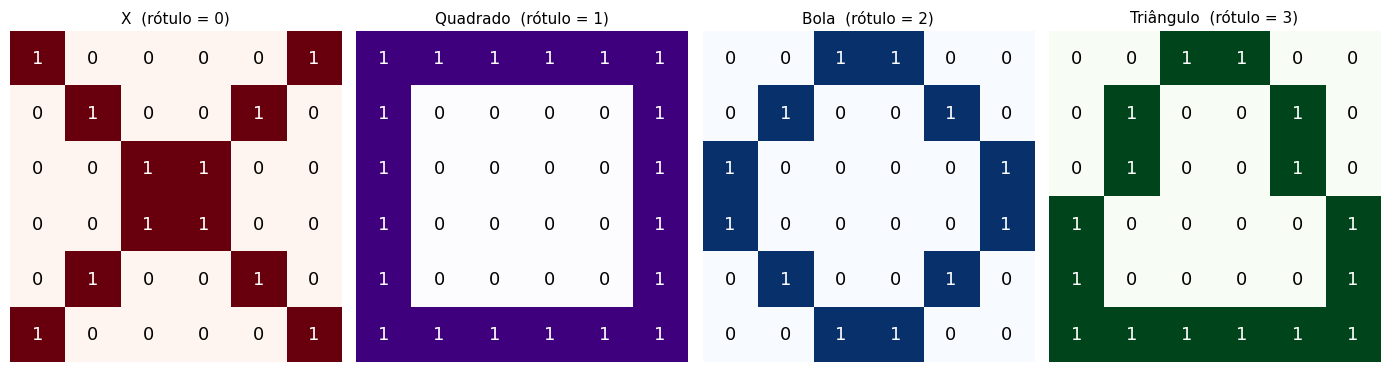

Dimensão de cada entrada: (6, 6)  (36 pixels)
Total de classes: 4
Treino: 2000 amostras | Teste: 800 amostras
Distribuição treino: [500 500 500 500]


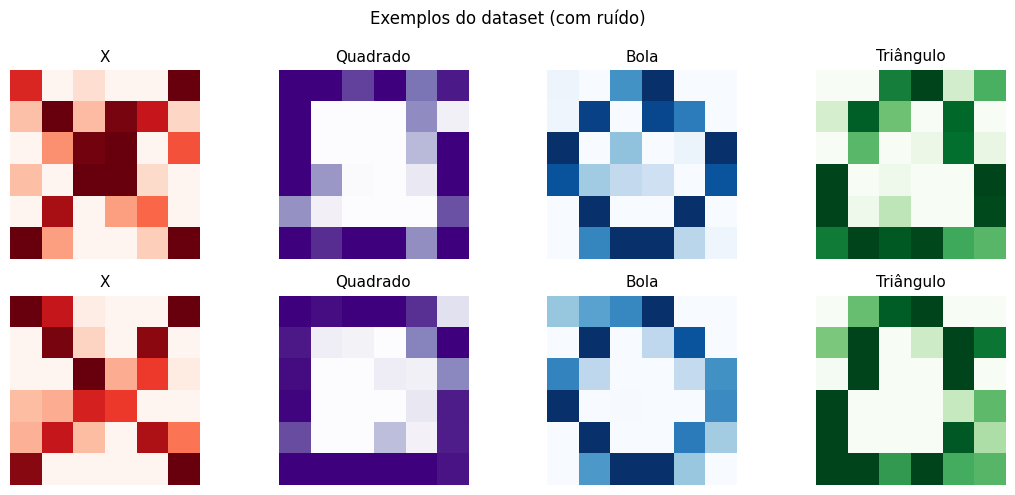

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# X (rótulo 0): duas diagonais cruzadas
X_base = np.array([
    [1, 0, 0, 0, 0, 1],
    [0, 1, 0, 0, 1, 0],
    [0, 0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0, 0],
    [0, 1, 0, 0, 1, 0],
    [1, 0, 0, 0, 0, 1]
], dtype=float)

# Quadrado (rótulo 1): contorno retangular
Q_base = np.array([
    [1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1]
], dtype=float)

# Bola (rótulo 2): contorno arredondado
B_base = np.array([
    [0, 0, 1, 1, 0, 0],
    [0, 1, 0, 0, 1, 0],
    [1, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 1],
    [0, 1, 0, 0, 1, 0],
    [0, 0, 1, 1, 0, 0]
], dtype=float)

# Triângulo (rótulo 3): apex no topo, base na linha de baixo
T_base = np.array([
    [0, 0, 1, 1, 0, 0],
    [0, 1, 0, 0, 1, 0],
    [0, 1, 0, 0, 1, 0],
    [1, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1]
], dtype=float)

padroes = [X_base, Q_base, B_base, T_base]
nomes   = ['X', 'Quadrado', 'Bola', 'Triângulo']
cmaps   = ['Reds', 'Purples', 'Blues', 'Greens']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, M, nome, cmap in zip(axes, padroes, nomes, cmaps):
    ax.imshow(M, cmap=cmap, vmin=0, vmax=1)
    for i in range(6):
        for j in range(6):
            ax.text(j, i, int(M[i, j]), ha='center', va='center',
                    fontsize=13, color='white' if M[i, j] > 0.5 else 'black')
    ax.set_title(f'{nome}  (rótulo = {nomes.index(nome)})', fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Dimensão de cada entrada: {X_base.shape}  ({X_base.size} pixels)')
print(f'Total de classes: {len(padroes)}')


def gerar_dataset(n_por_classe=500, ruido=0.4, seed=42):
    rng = np.random.default_rng(seed)
    X_data, y_data = [], []
    for label, base in enumerate(padroes):
        for _ in range(n_por_classe):
            X_data.append(np.clip(base + rng.normal(0, ruido, base.shape), 0, 1))
            y_data.append(label)
    perm = rng.permutation(len(X_data))
    return np.array(X_data)[perm], np.array(y_data)[perm]


X_train, y_train = gerar_dataset(n_por_classe=500, seed=42)
X_test,  y_test  = gerar_dataset(n_por_classe=200, seed=99)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'Distribuição treino: {np.bincount(y_train)}')

# Visualizar 2 exemplos de cada classe
fig, axes = plt.subplots(2, 4, figsize=(11, 5))
for col in range(4):
    idxs = np.where(y_train == col)[0][:2]
    for row, idx in enumerate(idxs):
        axes[row, col].imshow(X_train[idx], cmap=cmaps[col], vmin=0, vmax=1)
        axes[row, col].set_title(nomes[col], fontsize=11)
        axes[row, col].axis('off')
plt.suptitle('Exemplos do dataset (com ruído)', fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
def conv2d(X, W, b):
    kH, kW = W.shape
    H_out = X.shape[0] - kH + 1
    W_out = X.shape[1] - kW + 1
    Z = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            Z[i, j] = np.sum(X[i:i+kH, j:j+kW] * W) + b
    return Z

def relu(Z):
    return np.maximum(0, Z)

def maxpool(A, pool=2):
    H_out = A.shape[0] // pool
    W_out = A.shape[1] // pool
    M = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            M[i, j] = np.max(A[i*pool:(i+1)*pool, j*pool:(j+1)*pool])
    return M

def softmax(z):
    e = np.exp(z - np.max(z))
    return e / e.sum()

print('conv2d, relu, maxpool, softmax definidos')

conv2d, relu, maxpool, softmax definidos


In [4]:
def grad_conv2d(dZ, X, W):
    kH, kW = W.shape
    dW = np.zeros_like(W)
    db = float(np.sum(dZ))
    for i in range(dZ.shape[0]):
        for j in range(dZ.shape[1]):
            dW += dZ[i, j] * X[i:i+kH, j:j+kW]
    return dW, db

def grad_relu(dA, Z):
    return dA * (Z > 0)

def grad_maxpool(dM, A, pool=2):
    dA = np.zeros_like(A)
    for i in range(dM.shape[0]):
        for j in range(dM.shape[1]):
            bloco = A[i*pool:(i+1)*pool, j*pool:(j+1)*pool]
            idx = np.unravel_index(np.argmax(bloco), bloco.shape)
            dA[i*pool + idx[0], j*pool + idx[1]] = dM[i, j]
    return dA

print('Funções de gradiente definidas.')

Funções de gradiente definidas.


In [5]:
def forward(X, W_conv, b_conv, W_dense, b_dense):
    Z_conv = conv2d(X, W_conv, b_conv)          # (4, 4)
    A_conv = relu(Z_conv)                        # (4, 4)
    M      = maxpool(A_conv)                     # (2, 2)
    flat   = M.flatten()                         # (4,)
    probs  = softmax(W_dense @ flat + b_dense)   # (2,)
    cache  = (X, Z_conv, A_conv, M, flat)
    return probs, cache

def backward(probs, y_label, cache, W_conv, W_dense):
    X, Z_conv, A_conv, M, flat = cache

    y    = np.zeros(4); y[y_label] = 1.0
    dz_d = probs - y                                        # gradiente saída

    dW_dense = np.outer(dz_d, flat)                         # gradiente Dense
    db_dense = dz_d.copy()
    d_flat   = W_dense.T @ dz_d

    dA_conv  = grad_maxpool(d_flat.reshape(M.shape), A_conv)  # gradiente MaxPool
    dZ_conv  = grad_relu(dA_conv, Z_conv)                     # gradiente ReLU
    dW_conv, db_conv = grad_conv2d(dZ_conv, X, W_conv)        # gradiente Conv

    return dW_conv, db_conv, dW_dense, db_dense


def cross_entropy(probs, y_label):
    return -np.log(probs[y_label] + 1e-9)


def predict(X, W_conv, b_conv, W_dense, b_dense):
    probs, _ = forward(X, W_conv, b_conv, W_dense, b_dense)
    return np.argmax(probs)


print('foward, backward, cross_entropy e predict definidos.')

foward, backward, cross_entropy e predict definidos.


In [9]:
rng = np.random.default_rng(0)
W_conv  = rng.normal(0, 0.1, (3, 3))
b_conv  = 0.0
W_dense = rng.normal(0, 0.1, (4, 4))
b_dense = np.zeros(4)

# Loop de treinamento (SGD)
lr     = 0.05
epochs = 30
historico = []

for ep in range(epochs):
    perda_total = 0.0
    for i in np.random.permutation(len(X_train)):
        probs, cache = forward(X_train[i], W_conv, b_conv, W_dense, b_dense)
        perda_total += cross_entropy(probs, y_train[i])

        dW_conv, db_conv, dW_dense, db_dense = backward(probs, y_train[i], cache, W_conv, W_dense)

        W_conv  -= lr * dW_conv
        b_conv  -= lr * db_conv
        W_dense -= lr * dW_dense
        b_dense -= lr * db_dense

    historico.append(perda_total / len(X_train))
    if (ep + 1) % 10 == 0:
        print(f'Época {ep+1:3d}/{epochs}  |  Loss: {historico[-1]:.4f}')

print('\nTreinamento concluído.')

Época  10/30  |  Loss: 0.2236
Época  20/30  |  Loss: 0.2220
Época  30/30  |  Loss: 0.2229

Treinamento concluído.


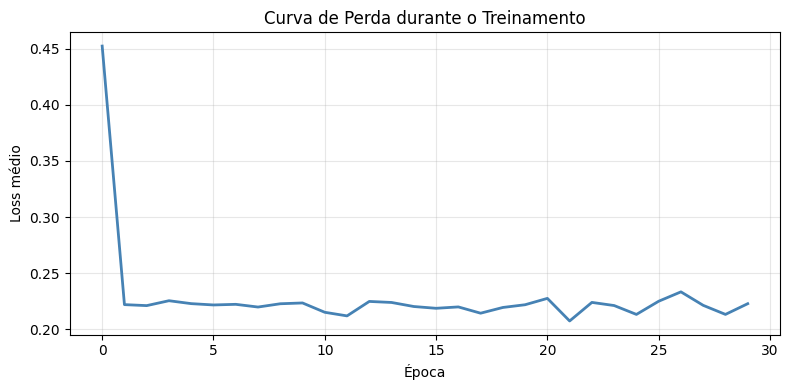

Acurácia no conjunto de teste: 92.8%


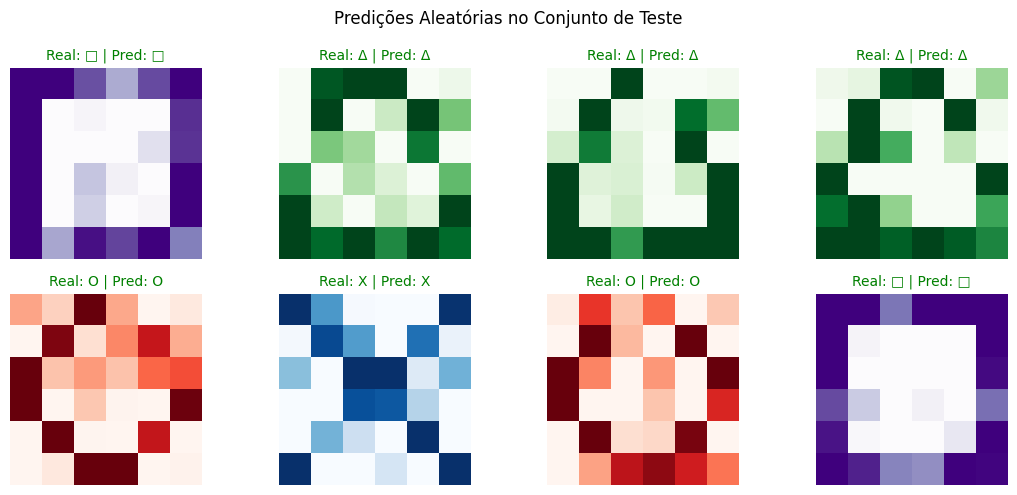

In [17]:
# Curva de perda
plt.figure(figsize=(8, 4))
plt.plot(historico, color='steelblue', linewidth=2)
plt.title('Curva de Perda durante o Treinamento')
plt.xlabel('Época'); plt.ylabel('Loss médio')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
cmap_map = {0: 'Blues', 1: 'Purples', 2: 'Reds', 3: 'Greens'}
label_map = {0: 'X', 1: '□', 2: 'O', 3: 'Δ'}

# Acurácia no teste
preds    = np.array([predict(X_test[i], W_conv, b_conv, W_dense, b_dense) for i in range(len(X_test))])
acuracia = (preds == y_test).mean() * 100
print(f'Acurácia no conjunto de teste: {acuracia:.1f}%')

# Visualizar predições

cmap_map = {0: 'Blues', 1: 'Purples', 2: 'Reds', 3: 'Greens'}
label_map = {0: 'X', 1: '□', 2: 'O', 3: 'Δ'}

indices_aleatorios = np.random.choice(len(y_test), size=8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(11, 5))

for i, ax in enumerate(axes.flat):
    idx = indices_aleatorios[i]
    real_label = label_map[y_test[idx]]
    pred_label = label_map[preds[idx]]

    ax.imshow(X_test[idx], cmap=cmap_map[y_test[idx]], vmin=0, vmax=1)

    cor_titulo = 'green' if y_test[idx] == preds[idx] else 'red'
    ax.set_title(f'Real: {real_label} | Pred: {pred_label}', color=cor_titulo, fontsize=10)

    ax.axis('off')

plt.suptitle('Predições Aleatórias no Conjunto de Teste', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Critérios de avaliação

| Critério | Peso |
|----------|------|
| Forward pass correto (conv → ReLU → pool → dense → softmax) para 4 classes | 20% |
| Backpropagation correto (gradientes coerentes em todas as camadas) | 25% |
| Treinamento estável com curva de loss decrescente | 15% |
| Acurácia no teste **≥ 85%** | 15% |
| Matriz de confusão e visualização das predições | 10% |
| Justificativas das escolhas de arquitetura (markdown) | 10% |
| Discussão final (confusões, ruído, comparação CNN vs FNN) | 5% |

---

## 7. Entrega

- **Formato:** notebook `.ipynb` executado, no padrão `cp_02_cnn_<nome_de_quem_enviou>.ipynb`.
- **Trabalho individual.** Códigos idênticos entre alunos serão zerados.
- **Prazo:** conforme combinado em sala / portal.

OBS: Os nomes dos membros do grupos devem estar na base do documento.

Bom trabalho!